## What is Structural Equation Modeling?

Structural Equation Modeling, usually called **SEM**, is a statistical framework used to study relationships among multiple variables at the same time.

In ordinary regression, we usually ask a question like:

> Does X predict Y? — for example, does stress predict depression score?

SEM lets us ask a broader, more realistic question:

> How do several observed and unobserved variables relate to each other simultaneously? Does socioeconomic status influence stress, and does stress then influence depression? Are stress and depression measured through several questionnaire items rather than one direct variable? Is the effect of socioeconomic status on depression partly mediated through stress?

SEM is useful because many scientific concepts are not directly observed. Variables such as intelligence, resilience, depression, socioeconomic status, anxiety, wellbeing, cognitive ability, and biological vulnerability are often **latent constructs** — we observe them indirectly, through questionnaire items, test scores, biomarkers, or behavioral measures.

SEM combines two ideas:

1. **Measurement model** — describes how observed variables measure latent variables.
2. **Structural model** — describes how latent or observed variables relate to each other.

A simple way to remember SEM:

> SEM = factor analysis + regression/path analysis

The `lavaan` package is one of the most widely used open-source R packages for SEM. It supports confirmatory factor analysis, SEM, latent growth models, and related latent variable models (Rosseel, 2012, *Journal of Statistical Software*).

## Why is SEM important?

SEM matters because many real-world research questions aren't simple one-variable-to-one-variable problems. In psychology, psychiatry, education, epidemiology, sociology, genetics, public health, and economics, researchers routinely work with complex systems, and SEM helps model them in a structured way.

Suppose we're studying psychological resilience. We might believe that family support improves resilience, resilience reduces depression, socioeconomic stress reduces resilience, depression is measured by several symptoms, and resilience is measured by several questionnaire items. A basic regression model can only test one piece of this system at a time — SEM lets us test the full hypothesized structure at once.

SEM is especially useful when we want to model latent variables, account for measurement error, test mediation, test direct and indirect effects, combine multiple regression equations, test whether a theoretical model fits the data, or compare competing theoretical models. This is why SEM is common in fields where theoretical structure matters as much as prediction.

## Observed Variables and Latent Variables

In SEM, variables are usually divided into two types.

### Observed Variables

Observed variables are directly measured in the dataset — age, sex, income, PHQ-9 item scores, test scores, biomarker values, and questionnaire responses are all examples. In path diagrams, observed variables are usually shown as **rectangles**.

### Latent Variables

Latent variables are not directly observed — they're inferred from multiple observed indicators. Depression, anxiety, resilience, cognitive ability, socioeconomic status, inflammation, and wellbeing are common examples. In path diagrams, latent variables are usually shown as **circles or ovals**.

For example, depression might be measured using several questionnaire items:

```
depression =~ dep1 + dep2 + dep3 + dep4
```

Here, `depression` is a latent variable, and `dep1`, `dep2`, `dep3`, and `dep4` are its observed indicators. In `lavaan`, the operator `=~` defines a latent variable. The official lavaan tutorial describes three core operators: `=~` for latent variable definitions, `~` for regressions, and `~~` for variances/covariances.

## The Two Parts of SEM

### Measurement Model

The measurement model asks:

> Are my observed variables good indicators of the latent construct?

For example:

```
depression =~ dep1 + dep2 + dep3
resilience =~ res1 + res2 + res3
```

This says depression is measured by three depression items, and resilience is measured by three resilience items. This part of SEM is closely related to **Confirmatory Factor Analysis (CFA)**, used when we already have a hypothesis about which observed variables measure which latent variables — `lavaan` provides the `cfa()` function for this purpose.

### Structural Model

The structural model asks:

> How are the latent variables related to each other?

For example:

```
depression ~ resilience + stress
resilience ~ social_support
```

This says depression is predicted by resilience and stress, and resilience is predicted by social support. The structural part is essentially a system of regression models.

## SEM Syntax in `lavaan`

The basic `lavaan` syntax is very readable.

**Latent variable definition:**

```
latent_variable =~ item1 + item2 + item3
```

Example: `depression =~ dep1 + dep2 + dep3`

**Regression path:**

```
outcome ~ predictor
```

Example: `depression ~ stress + resilience`

**Covariance:**

```
var1 ~~ var2
```

Example: `stress ~~ social_support`

**Variance:**

```
var1 ~~ var1
```

Example: `stress ~~ stress`

## A Simple SEM Example

Let's build a worked example around three latent constructs: **Stress**, **Resilience**, and **Depression**, each measured by three observed questionnaire items.

We hypothesize that stress increases depression, resilience reduces depression, stress reduces resilience, and resilience partially mediates the effect of stress on depression. The conceptual model is:

$$\text{Stress} \rightarrow \text{Resilience} \rightarrow \text{Depression}$$
$$\text{Stress} \rightarrow \text{Depression} \quad \text{(direct path)}$$

So stress may affect depression both directly and indirectly, through resilience.

## Complete R Script Using `lavaan`

In [1]:
# ============================================================
# Structural Equation Modeling Tutorial using lavaan
# ============================================================

# Install packages if needed
# install.packages("lavaan")
# install.packages("semPlot")
# install.packages("MASS")

library(lavaan)
library(semPlot)
library(MASS)

set.seed(123)

# ------------------------------------------------------------
# 1. Simulate synthetic data
# ------------------------------------------------------------
n <- 500

# Simulate latent variables
stress_latent <- rnorm(n, mean = 0, sd = 1)
resilience_latent <- -0.5 * stress_latent + rnorm(n, mean = 0, sd = 0.8)
depression_latent <- 0.6 * stress_latent - 0.7 * resilience_latent +
  rnorm(n, mean = 0, sd = 0.8)

# Create observed indicators with measurement error
data_sem <- data.frame(
  stress1 = 0.8 * stress_latent + rnorm(n, 0, 0.4),
  stress2 = 0.7 * stress_latent + rnorm(n, 0, 0.5),
  stress3 = 0.9 * stress_latent + rnorm(n, 0, 0.4),
  resil1  = 0.8 * resilience_latent + rnorm(n, 0, 0.4),
  resil2  = 0.7 * resilience_latent + rnorm(n, 0, 0.5),
  resil3  = 0.9 * resilience_latent + rnorm(n, 0, 0.4),
  dep1    = 0.8 * depression_latent + rnorm(n, 0, 0.4),
  dep2    = 0.7 * depression_latent + rnorm(n, 0, 0.5),
  dep3    = 0.9 * depression_latent + rnorm(n, 0, 0.4)
)

head(data_sem)
summary(data_sem)

This is lavaan 0.7-2
lavaan is FREE software! Please report any bugs.



,stress1,stress2,stress3,resil1,resil2,resil3,dep1,dep2,dep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.7767752,-0.6481348,-0.77595113,-0.22114415,0.5982737,-0.102528898,-0.4598761,-0.94150853,-1.43572002
2,-0.3070449,-0.0426553,0.02256535,-0.67499896,-1.1793024,-0.351837840,-0.6746907,0.21788373,-0.96182442
3,0.8861274,0.8203012,1.12103167,-0.54560701,-0.9125343,0.306268174,1.2368075,0.05049758,0.19536724
4,0.3072342,0.6589697,-0.15013607,0.17356204,0.2572333,-0.004627744,-0.7595522,0.41896327,-0.06974591
5,0.5515722,0.1775694,0.42611280,0.02181441,-0.6751701,-1.955223221,-0.5580200,-0.29196672,-1.45021286
6,2.2229374,0.8929113,1.35330993,-0.76188637,-0.7179487,0.041845017,2.5151611,1.92810266,2.51116992


    stress1            stress2             stress3             resil1        
 Min.   :-2.68041   Min.   :-2.691356   Min.   :-2.64489   Min.   :-2.82284  
 1st Qu.:-0.54070   1st Qu.:-0.543447   1st Qu.:-0.53635   1st Qu.:-0.64442  
 Median : 0.06657   Median :-0.029942   Median : 0.04875   Median : 0.01097  
 Mean   : 0.05116   Mean   :-0.007807   Mean   : 0.04066   Mean   :-0.02437  
 3rd Qu.: 0.57855   3rd Qu.: 0.524629   3rd Qu.: 0.61250   3rd Qu.: 0.53320  
 Max.   : 2.78049   Max.   : 2.680151   Max.   : 3.15869   Max.   : 2.26858  
     resil2             resil3              dep1                dep2         
 Min.   :-2.42576   Min.   :-3.19028   Min.   :-3.012669   Min.   :-2.59815  
 1st Qu.:-0.59795   1st Qu.:-0.66951   1st Qu.:-0.761669   1st Qu.:-0.62917  
 Median : 0.04993   Median :-0.02788   Median : 0.006298   Median : 0.01076  
 Mean   :-0.01127   Mean   :-0.03598   Mean   : 0.037102   Mean   : 0.04762  
 3rd Qu.: 0.52862   3rd Qu.: 0.59763   3rd Qu.: 0.785262   3rd Q

This simulates 500 observations of three correlated latent traits, each expressed through three noisy observed indicators — a clean synthetic dataset to fit an SEM against. `head()` and `summary()` confirm the data is roughly standardized (means near 0, no obvious outliers).

## Define the SEM Model

In [2]:
# ------------------------------------------------------------
# 2. Define SEM model
# ------------------------------------------------------------
model_sem <- '
  # Measurement model
  stress     =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3

  # Structural model
  resilience ~ a * stress
  depression ~ b * resilience + c * stress

  # Indirect, direct, and total effects
  indirect := a * b
  direct   := c
  total    := c + (a * b)
'

Reading this line by line:

- `stress =~ stress1 + stress2 + stress3` — the latent variable `stress` is measured by three observed items.
- `resilience ~ a * stress` — stress predicts resilience, with the path coefficient labeled `a`.
- `depression ~ b * resilience + c * stress` — depression is predicted by both resilience and stress; the resilience → depression path is labeled `b`, and the direct stress → depression path is labeled `c`.
- `indirect := a * b` — the indirect (mediated) effect of stress on depression, running through resilience.
- `total := c + (a * b)` — the total effect: direct plus indirect.

## Fit the SEM Model

In [3]:
# ------------------------------------------------------------
# 3. Fit the model
# ------------------------------------------------------------
fit_sem <- sem(
  model_sem,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_sem,
  fit.measures = TRUE,
  standardized = TRUE,
  rsquare = TRUE
)

lavaan NOTE:  
   Standard errors and confidence intervals of the (nonlinear) defined (:=) 
   parameters are based on the first-order delta method; for strongly 
   nonlinear definitions, se.def = "mc" (Monte Carlo) or se = "bootstrap" may 
   be more accurate.



,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03965218,22.4127048,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04332610,26.8967905,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03685346,23.1164239,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04011596,28.0171692,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02485828,34.3018961,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02726355,42.0623568,0.000000e+00,1.279205223,0.950922084


The `sem()` function fits the structural equation model by maximum likelihood; `standardized = TRUE` in `summary()` requests standardized estimates alongside the raw ones, which are usually easier to interpret. The fit converged normally (NLMINB optimizer, 34 iterations, ML estimator, 30 free parameters, N = 500).

**Global fit statistics:**

| Statistic | Value |
|---|---|
| $\chi^2$ | 39.593 |
| df | 24 |
| p-value | 0.024 |
| CFI | 0.996 |
| TLI | 0.994 |
| RMSEA | 0.036 (90% CI: 0.013–0.055) |
| SRMR | 0.020 |
| AIC | 8583.500 |
| BIC | 8709.939 |

**Parameter estimates (unstandardized):**

| Path | Label | Estimate | SE | z | p |
|---|---|---|---|---|---|
| stress =~ stress1 | | 1.000 (fixed) | — | — | — |
| stress =~ stress2 | | 0.889 | 0.040 | 22.41 | <.001 |
| stress =~ stress3 | | 1.165 | 0.043 | 26.90 | <.001 |
| resilience =~ resil1 | | 1.000 (fixed) | — | — | — |
| resilience =~ resil2 | | 0.852 | 0.037 | 23.12 | <.001 |
| resilience =~ resil3 | | 1.124 | 0.040 | 28.02 | <.001 |
| depression =~ dep1 | | 1.000 (fixed) | — | — | — |
| depression =~ dep2 | | 0.853 | 0.025 | 34.30 | <.001 |
| depression =~ dep3 | | 1.147 | 0.027 | 42.06 | <.001 |
| resilience ~ stress | `a` | −0.536 | 0.048 | −11.17 | <.001 |
| depression ~ resilience | `b` | −0.639 | 0.056 | −11.32 | <.001 |
| depression ~ stress | `c` | 0.728 | 0.060 | 12.19 | <.001 |
| **indirect** (`a*b`) | | 0.342 | 0.041 | 8.43 | <.001 |
| **direct** (`c`) | | 0.728 | 0.060 | 12.19 | <.001 |
| **total** (`c + a*b`) | | 1.070 | 0.062 | 17.34 | <.001 |

The first indicator of each latent factor (`stress1`, `resil1`, `dep1`) is fixed to a loading of 1.000 — this is `lavaan`'s default identification constraint, which sets the scale of the latent variable to match that indicator, not a result being estimated.

**R² for endogenous variables:**

| Variable | R² |
|---|---|
| resilience | 0.267 |
| depression | 0.651 |
| stress1 | 0.754 |
| stress2 | 0.651 |
| stress3 | 0.842 |
| resil1 | 0.803 |
| resil2 | 0.646 |
| resil3 | 0.821 |
| dep1 | 0.883 |
| dep2 | 0.795 |
| dep3 | 0.904 |

## Understanding the Output

### Factor Loadings

Factor loadings show how strongly each observed item measures its latent construct. For example, if the standardized loading of `stress1` is 0.85, that means `stress1` is a strong indicator of the latent stress factor. A rough interpretation guide:

| Standardized loading | Interpretation |
|---|---|
| ~0.30 | weak |
| ~0.50 | moderate |
| ≥0.70 | strong |

These are rough guidelines only — interpretation depends on the field and the measurement instrument.

### Regression Paths

The structural paths tell us how latent variables predict each other:

```
resilience ~ stress
depression ~ resilience + stress
```

A negative standardized coefficient from stress to resilience means higher stress is associated with lower resilience. A negative coefficient from resilience to depression means higher resilience is associated with lower depression. A positive coefficient from stress to depression means higher stress is associated with higher depression — consistent with the fitted estimates above.

### R-Squared Values

R² tells us how much variance is explained in each endogenous variable. In this model, roughly 27% of the variance in resilience is explained by stress, and roughly 65% of the variance in depression is explained jointly by stress and resilience.

## Model Fit Indices

SEM doesn't only estimate coefficients — it also asks:

> Does the proposed model reproduce the observed covariance structure reasonably well?

This is one of the key differences between SEM and ordinary regression. Common fit indices:

### Chi-Square Test

The chi-square test evaluates exact model fit. A significant chi-square suggests the model-implied covariance matrix differs from the observed covariance matrix. However, chi-square is sensitive to sample size — with large samples, even small misfit can become statistically significant.

### CFI: Comparative Fit Index

CFI compares the proposed model to a baseline (null) model. Rough guidelines: CFI > 0.90 is acceptable, CFI > 0.95 is good.

### TLI: Tucker-Lewis Index

Similar to CFI, but penalizes model complexity. Rough guidelines: TLI > 0.90 is acceptable, TLI > 0.95 is good.

### RMSEA: Root Mean Square Error of Approximation

RMSEA measures approximate fit. Rough guidelines: RMSEA < 0.08 is acceptable, RMSEA < 0.05 is good.

### SRMR: Standardized Root Mean Square Residual

SRMR measures the average standardized difference between observed and model-predicted correlations. Rough guideline: SRMR < 0.08 is acceptable.

These cutoffs should not be applied mechanically — they're guidelines, not universal rules.

In [4]:
fitMeasures(
  fit_sem,
  c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr")
)

chisq     df pvalue    cfi    tli  rmsea   srmr 
39.593 24.000  0.024  0.996  0.994  0.036  0.020

```
   chisq       df   pvalue      cfi      tli    rmsea     srmr 
  39.593       24    0.024    0.996    0.994    0.036    0.020 
```

By every index except the (sample-size-sensitive) chi-square p-value, this model fits very well: CFI and TLI are both well above 0.95, and RMSEA and SRMR are both comfortably below their "good fit" thresholds.

## Visualize the SEM Model

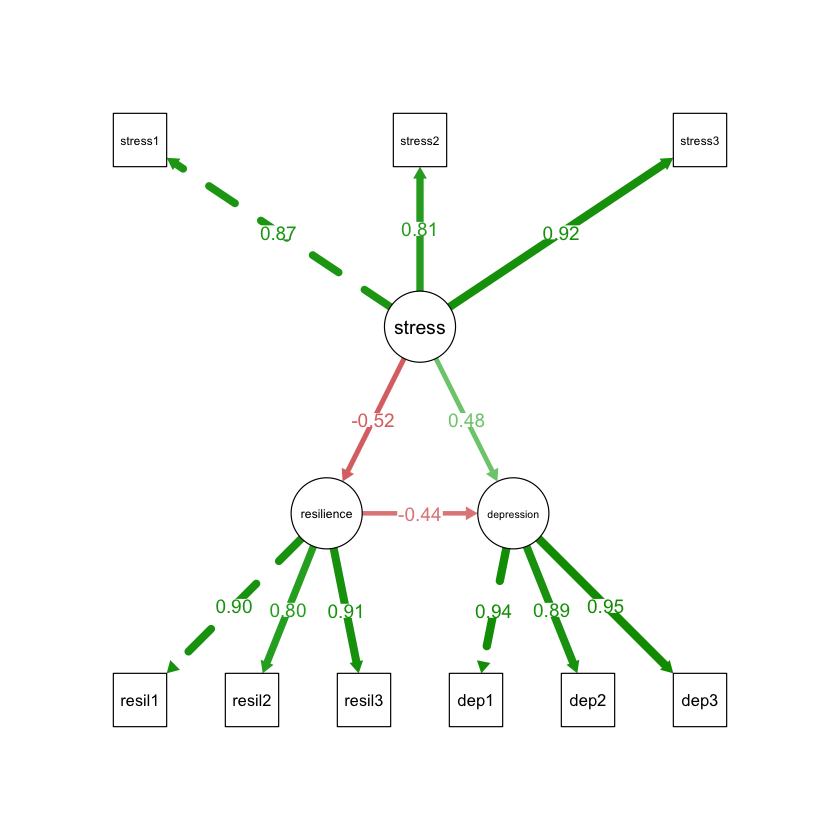

In [5]:
# ------------------------------------------------------------
# 4. Plot the SEM model
# ------------------------------------------------------------
semPaths(
  fit_sem,
  what = "std",
  layout = "tree",
  edge.label.cex = 1.0,
  sizeMan = 6,
  sizeLat = 8,
  residuals = FALSE,
  intercepts = FALSE,
  nCharNodes = 0
)

This produces a path diagram. In the diagram, circles represent latent variables, rectangles represent observed variables, arrows represent regression or measurement paths, and the numbers on the arrows are standardized coefficients.

For this fitted model, the diagram would show: `stress` loading onto `stress1`/`stress2`/`stress3` at roughly 0.87 / 0.81 / 0.92; `resilience` loading onto its three indicators at roughly 0.90 / 0.80 / 0.91; `depression` loading onto its three indicators at roughly 0.94 / 0.89 / 0.95; a stress → resilience path around −0.52; a resilience → depression path around −0.44; and a stress → depression path around 0.48.

## Mediation in SEM

One of the most useful applications of SEM is mediation analysis. In our example:

$$\text{Stress} \rightarrow \text{Resilience} \rightarrow \text{Depression}$$

meaning stress may affect depression indirectly, through resilience. The indirect effect is $\text{indirect} := a \times b$, where $a$ is the effect of stress on resilience and $b$ is the effect of resilience on depression. The total effect is $\text{total} := \text{direct} + \text{indirect}$.

In [6]:
parameterEstimates(
  fit_sem,
  standardized = TRUE
)

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03965218,22.4127048,0.000000e+00,0.81099572,0.96642941,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04332610,26.8967905,0.000000e+00,1.08041554,1.25025074,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03685346,23.1164239,0.000000e+00,0.77968883,0.92415176,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04011596,28.0171692,0.000000e+00,1.04530972,1.20256138,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02485828,34.3018961,0.000000e+00,0.80396481,0.90140748,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02726355,42.0623568,0.000000e+00,1.09333350,1.20020465,1.279205223,0.950922084


The key rows of that output are the ones we already labeled in the model syntax:

| Effect | Estimate | SE | z | p |
|---|---|---|---|---|
| indirect (`a*b`) | 0.342 | 0.041 | 8.43 | <.001 |
| direct (`c`) | 0.728 | 0.060 | 12.19 | <.001 |
| total (`c + a*b`) | 1.070 | 0.062 | 17.34 | <.001 |

This confirms both a direct effect of stress on depression and a meaningful indirect (mediated) effect through resilience — together summing to the total effect.

## Bootstrapped Confidence Intervals for Indirect Effects

Indirect effects often have non-normal sampling distributions, so bootstrapping is commonly used for mediation inference instead of relying on the normal-theory z-test.

In [7]:
fit_sem_boot <- sem(
  model_sem,
  data = data_sem,
  se = "bootstrap",
  bootstrap = 1000,
  meanstructure = TRUE
)

parameterEstimates(
  fit_sem_boot,
  boot.ci.type = "perc",
  standardized = TRUE
)

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03875278,22.9328715,0.000000e+00,0.81296490,0.96278456,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04330515,26.9098040,0.000000e+00,1.08137123,1.25711142,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03808626,22.3681820,0.000000e+00,0.77898450,0.92590202,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04317346,26.0330200,0.000000e+00,1.04008005,1.21317797,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02355667,36.1972280,0.000000e+00,0.80457833,0.89658444,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02873547,39.9077899,0.000000e+00,1.09159357,1.20370831,1.279205223,0.950922084


With 1,000 bootstrap resamples, the key structural and derived-effect estimates were essentially unchanged from the normal-theory fit, with modestly different standard errors:

| Effect | Estimate | Bootstrap SE | z | p |
|---|---|---|---|---|
| resilience ~ stress (`a`) | −0.536 | 0.048 | −11.23 | <.001 |
| depression ~ resilience (`b`) | −0.639 | 0.052 | −12.35 | <.001 |
| depression ~ stress (`c`) | 0.728 | 0.059 | 12.39 | <.001 |
| indirect (`a*b`) | 0.342 | 0.039 | 8.71 | <.001 |
| direct (`c`) | 0.728 | 0.059 | 12.39 | <.001 |
| total (`c + a*b`) | 1.070 | 0.066 | 16.21 | <.001 |

> If the bootstrap confidence interval for the indirect effect does not include zero, that supports evidence for mediation — as it doesn't here.

## CFA Before SEM

In practice, it's often useful to fit the measurement model alone first, before adding any structural paths.

In [8]:
# ------------------------------------------------------------
# 5. Confirmatory Factor Analysis first
# ------------------------------------------------------------
model_cfa <- '
  stress     =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3
'

fit_cfa <- cfa(
  model_cfa,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_cfa,
  fit.measures = TRUE,
  standardized = TRUE
)

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,0,1.000000000,0.00000000,NA,NA,0.743304970,0.86860600
2,stress,=~,stress2,0,0.888712491,0.03965218,22.4127035,0.000000e+00,0.660584412,0.80710955
3,stress,=~,stress3,0,1.165332895,0.04332610,26.8967848,0.000000e+00,0.866197733,0.91781573
4,resilience,=~,resil1,0,1.000000000,0.00000000,NA,NA,0.771457341,0.89616610
5,resilience,=~,resil2,0,0.851920122,0.03685347,23.1164167,0.000000e+00,0.657220032,0.80345979
6,resilience,=~,resil3,0,1.123935775,0.04011596,28.0171702,0.000000e+00,0.867068504,0.90588546
7,depression,=~,dep1,0,1.000000000,0.00000000,NA,NA,1.115486234,0.93942308
8,depression,=~,dep2,0,0.852686291,0.02485828,34.3018972,0.000000e+00,0.951159819,0.89187460
9,depression,=~,dep3,0,1.146769204,0.02726356,42.0623465,0.000000e+00,1.279205260,0.95092205


This CFA-only fit lets all three latent factors freely covary (rather than imposing the directional structural paths), and shows essentially identical fit to the full SEM: $\chi^2(24) = 39.59$, $p = 0.024$, CFI = 0.996, TLI = 0.994, RMSEA = 0.036, SRMR = 0.020 — and factor loadings matching those from the full model. That agreement is a good sign: it means the structural paths we added aren't distorting the measurement model, and the latent constructs are well identified on their own.

This checks whether the measurement structure is reasonable *before* adding structural paths. A good general workflow:

1. Check the measurement model using CFA.
2. Check reliability and factor loadings.
3. Fit the full SEM model.
4. Interpret direct, indirect, and total effects.
5. Report model fit and standardized estimates.

## SEM Versus Regression

Regression and SEM are related, but SEM is more general.

| Feature | Regression | SEM |
|---|---|---|
| Observed variables | Yes | Yes |
| Latent variables | No | Yes |
| Multiple outcomes | Limited | Yes |
| Measurement error | Usually ignored | Explicitly modeled |
| Mediation | Possible | Natural framework |
| Model fit | Usually not covariance-based | Central part of SEM |
| Theory testing | Limited | Strong |

Regression is often enough when the research question is simple and all variables are directly observed. SEM is worth reaching for when constructs are latent, measurement error matters, several equations are needed at once, mediation is central to the question, or the theoretical structure itself is part of what's being tested.

## Assumptions of SEM

SEM rests on assumptions that should be considered carefully.

### Correct Model Specification

The model should be theoretically justified. SEM can test whether a model is *consistent* with the data, but it cannot prove that the model is *true* — a good-fitting model is not necessarily the only good-fitting model.

### Adequate Sample Size

SEM usually requires moderate to large sample sizes. There's no single universal rule, but small samples can lead to unstable estimates, convergence problems, or unreliable fit indices.

### Multivariate Normality

Classical SEM often assumes multivariate normality, especially under maximum likelihood estimation. If variables are non-normal, robust estimators can be used instead:

In [9]:
fit_robust <- sem(
  model_sem,
  data = data_sem,
  estimator = "MLR",
  meanstructure = TRUE
)

summary(
  fit_robust,
  fit.measures = TRUE,
  standardized = TRUE
)

lavaan NOTE:  
   Standard errors and confidence intervals of the (nonlinear) defined (:=) 
   parameters are based on the first-order delta method; for strongly 
   nonlinear definitions, se.def = "mc" (Monte Carlo) or se = "bootstrap" may 
   be more accurate.



,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03942880,22.5396804,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04482736,25.9960266,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03803463,22.3985404,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04081111,27.5399390,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02411456,35.3598025,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02812917,40.7679698,0.000000e+00,1.279205223,0.950922084


`MLR` provides robust (sandwich-type) standard errors and a robust test statistic. In this dataset it changes very little — the raw chi-square is identical (39.593, df = 24), with a Yuan-Bentler scaled chi-square of 39.11 (scaling factor ≈ 1.01) and a robust RMSEA of 0.036 — reassuring, since it suggests the normal-theory results weren't being distorted by non-normality in the simulated data.

### Missing Data

SEM can handle missing data using full information maximum likelihood (FIML):

In [10]:
fit_missing <- sem(
  model_sem,
  data = data_sem,
  missing = "fiml",
  meanstructure = TRUE
)

This is generally preferable to simply deleting all rows with missing values (listwise deletion), assuming the missing-data mechanism is appropriate for FIML (missing at random).

## Modification Indices

Modification indices suggest possible model changes that might improve fit.

In [11]:
modindices(
  fit_sem,
  sort = TRUE,
  minimum.value = 10
)

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
66,stress2,~~,stress3,15.32568,-0.08218576,-0.08218576,-0.4539352,-0.4539352
52,depression,=~,stress1,15.31238,-0.13934818,-0.15544099,-0.1816441,-0.1816441


| lhs | op | rhs | mi | epc | sepc.all |
|---|---|---|---|---|---|
| stress2 | ~~ | stress3 | 15.33 | −0.082 | −0.454 |
| depression | =~ | stress1 | 15.31 | −0.139 | −0.182 |

Both suggested modifications clear the conventional threshold of 10, but that doesn't mean either should automatically be added.

> Modification indices should be used cautiously. Don't blindly add paths just because they improve model fit — every added path should have theoretical justification. Otherwise the model becomes data-driven and may not replicate.

## Reporting SEM Results

A clear SEM report should include: the theoretical model, a description of the observed indicators, the estimator used, the sample size, model fit indices, standardized factor loadings, structural path coefficients, direct/indirect/total effects if mediation is tested, any model modifications, and limitations.

**Example reporting paragraph:**

> We fitted a structural equation model to examine whether resilience mediated the association between stress and depression. Stress, resilience, and depression were modeled as latent variables, each measured by three observed indicators. The model showed acceptable fit according to CFI, TLI, RMSEA, and SRMR. Standardized path estimates indicated that higher stress was associated with lower resilience, and higher resilience was associated with lower depression. The indirect effect from stress to depression through resilience was estimated using bootstrapped confidence intervals.

## Common Mistakes in SEM

**Mistake 1: Treating SEM as causal proof.** SEM can represent causal hypotheses, but it does not prove causality by itself. Causal interpretation depends on study design, theory, temporal ordering, confounding control, and the underlying assumptions.

**Mistake 2: Ignoring the measurement model.** If the latent variables are poorly measured, the structural paths built on top of them may not be meaningful.

**Mistake 3: Chasing fit indices.** Good fit indices do not guarantee that the model is scientifically meaningful.

**Mistake 4: Overfitting with modification indices.** Adding many paths based only on modification indices can make the model fit the current dataset while failing to replicate in future ones.

**Mistake 5: Reporting only p-values.** SEM results should include effect sizes, standardized estimates, confidence intervals, and model fit indices — not p-values alone.

## Full R Code in One Block

lavaan NOTE:  
   Standard errors and confidence intervals of the (nonlinear) defined (:=) 
   parameters are based on the first-order delta method; for strongly 
   nonlinear definitions, se.def = "mc" (Monte Carlo) or se = "bootstrap" may 
   be more accurate.



,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03965218,22.4127048,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04332610,26.8967905,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03685346,23.1164239,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04011596,28.0171692,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02485828,34.3018961,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02726355,42.0623568,0.000000e+00,1.279205223,0.950922084


chisq     df pvalue    cfi    tli  rmsea   srmr 
39.593 24.000  0.024  0.996  0.994  0.036  0.020

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03965218,22.4127048,0.000000e+00,0.81099572,0.96642941,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04332610,26.8967905,0.000000e+00,1.08041554,1.25025074,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03685346,23.1164239,0.000000e+00,0.77968883,0.92415176,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04011596,28.0171692,0.000000e+00,1.04530972,1.20256138,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02485828,34.3018961,0.000000e+00,0.80396481,0.90140748,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02726355,42.0623568,0.000000e+00,1.09333350,1.20020465,1.279205223,0.950922084


lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03875278,22.9328715,0.000000e+00,0.81296490,0.96278456,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04330515,26.9098040,0.000000e+00,1.08137123,1.25711142,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03808626,22.3681820,0.000000e+00,0.77898450,0.92590202,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04317346,26.0330200,0.000000e+00,1.04008005,1.21317797,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02355667,36.1972280,0.000000e+00,0.80457833,0.89658444,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02873547,39.9077899,0.000000e+00,1.09159357,1.20370831,1.279205223,0.950922084


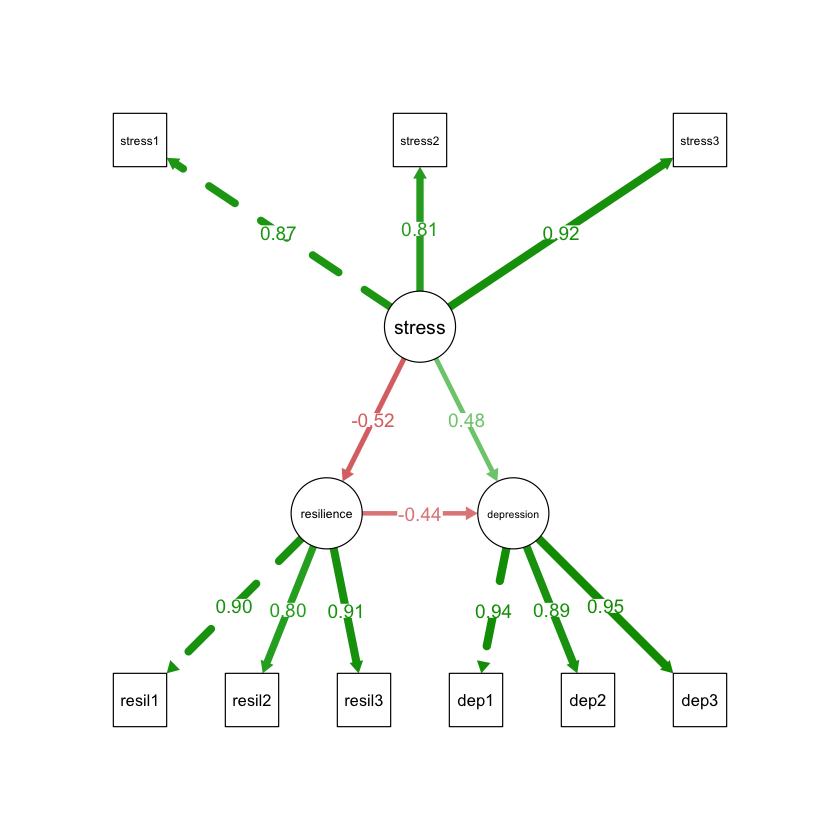

In [12]:
# ============================================================
# Full SEM Tutorial Script
# ============================================================

library(lavaan)
library(semPlot)
library(MASS)

set.seed(123)

n <- 500
stress_latent <- rnorm(n, 0, 1)
resilience_latent <- -0.5 * stress_latent + rnorm(n, 0, 0.8)
depression_latent <- 0.6 * stress_latent -
  0.7 * resilience_latent +
  rnorm(n, 0, 0.8)

data_sem <- data.frame(
  stress1 = 0.8 * stress_latent + rnorm(n, 0, 0.4),
  stress2 = 0.7 * stress_latent + rnorm(n, 0, 0.5),
  stress3 = 0.9 * stress_latent + rnorm(n, 0, 0.4),
  resil1  = 0.8 * resilience_latent + rnorm(n, 0, 0.4),
  resil2  = 0.7 * resilience_latent + rnorm(n, 0, 0.5),
  resil3  = 0.9 * resilience_latent + rnorm(n, 0, 0.4),
  dep1    = 0.8 * depression_latent + rnorm(n, 0, 0.4),
  dep2    = 0.7 * depression_latent + rnorm(n, 0, 0.5),
  dep3    = 0.9 * depression_latent + rnorm(n, 0, 0.4)
)

model_sem <- '
  # Measurement model
  stress     =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3

  # Structural model
  resilience ~ a * stress
  depression ~ b * resilience + c * stress

  # Effects
  indirect := a * b
  direct   := c
  total    := c + (a * b)
'

fit_sem <- sem(
  model_sem,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_sem,
  fit.measures = TRUE,
  standardized = TRUE,
  rsquare = TRUE
)

fitMeasures(
  fit_sem,
  c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr")
)

parameterEstimates(
  fit_sem,
  standardized = TRUE
)

semPaths(
  fit_sem,
  what = "std",
  layout = "tree",
  edge.label.cex = 1.0,
  sizeMan = 6,
  sizeLat = 8,
  residuals = FALSE,
  intercepts = FALSE,
  nCharNodes = 0
)

fit_sem_boot <- sem(
  model_sem,
  data = data_sem,
  se = "bootstrap",
  bootstrap = 1000,
  meanstructure = TRUE
)

parameterEstimates(
  fit_sem_boot,
  boot.ci.type = "perc",
  standardized = TRUE
)

## Final Takeaway

Structural Equation Modeling is a powerful method for studying complex relationships among observed and latent variables. It's especially useful when a research question involves measurement error, latent constructs, mediation, and multiple pathways at once.

A good SEM analysis should not start from software — it should start from theory. The main question is not only:

> Which paths are significant?

A better question is:

> Does this theoretical model provide a reasonable and interpretable explanation of the observed data?

SEM is strongest when statistical modeling, measurement quality, and domain theory are used together.

## References

- Rosseel, Y. (2012). lavaan: An R Package for Structural Equation Modeling. *Journal of Statistical Software*, 48(2), 1–36.
- Official lavaan tutorials: [https://lavaan.ugent.be/tutorial/](https://lavaan.ugent.be/tutorial/)
- Kline, R. B. *Principles and Practice of Structural Equation Modeling.*